# Modelo Visual — Blendshapes Temporais para Detecção de A/H
Pipeline: .npy blendshape features → vetorização temporal → XGBoost baseline + LSTM

Mesmo pipeline do visual_model.ipynb (AUs), trocando 20 AUs por 52 blendshapes.

In [1]:
# CÉLULA 1: Imports e configuração
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === PATHS ===
#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
BASE_DIR = r'\ABAW\data'

SPLIT_DIR = os.path.join(BASE_DIR, 'split')
BS_DIR = os.path.join(BASE_DIR, 'blendshape_features')

INPUT_DIM = 52  # blendshapes

BS_NAMES = [
    '_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft',
    'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight',
    'eyeBlinkLeft', 'eyeBlinkRight', 'eyeLookDownLeft', 'eyeLookDownRight',
    'eyeLookInLeft', 'eyeLookInRight', 'eyeLookOutLeft', 'eyeLookOutRight',
    'eyeLookUpLeft', 'eyeLookUpRight', 'eyeSquintLeft', 'eyeSquintRight',
    'eyeWideLeft', 'eyeWideRight', 'jawForward', 'jawLeft', 'jawOpen',
    'jawRight', 'mouthClose', 'mouthDimpleLeft', 'mouthDimpleRight',
    'mouthFrownLeft', 'mouthFrownRight', 'mouthFunnel', 'mouthLeft',
    'mouthLowerDownLeft', 'mouthLowerDownRight', 'mouthPressLeft',
    'mouthPressRight', 'mouthPucker', 'mouthRight', 'mouthRollLower',
    'mouthRollUpper', 'mouthShrugLower', 'mouthShrugUpper', 'mouthSmileLeft',
    'mouthSmileRight', 'mouthStretchLeft', 'mouthStretchRight', 'mouthUpperUpLeft',
    'mouthUpperUpRight', 'noseSneerLeft', 'noseSneerRight'
]

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Input dim: {INPUT_DIM} blendshapes")
print(f"BS features dir: {BS_DIR}")

Device: cuda
Input dim: 52 blendshapes
BS features dir: C:\Users\ddonz\OneDrive\Documentos\Aislan\data\blendshape_features


In [2]:
# CÉLULA 2: Carregar splits e mapear para arquivos .npy

def load_split_with_bs(split_file, bs_dir, excluded_ids):
    data = []
    missing = 0
    excluded = 0
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1].replace('.mp4', '')
            
            if pid in excluded_ids:
                excluded += 1
                continue
            
            # Tentar achar .npy (com ou sem .mp4 no nome)
            npy_path = None
            for suffix in [f'{video_name}.mp4.npy', f'{video_name}.npy']:
                p = os.path.join(bs_dir, pid, suffix)
                if os.path.exists(p):
                    npy_path = p
                    break
            
            if npy_path is None:
                missing += 1
                continue
            
            data.append({
                'pid': pid,
                'video_name': video_name,
                'npy_path': npy_path,
                'label': label
            })
    
    return data, missing, excluded

train_data, train_miss, train_excl = load_split_with_bs(
    os.path.join(SPLIT_DIR, 'train.txt'), BS_DIR, EXCLUDED_IDS)
val_data, val_miss, val_excl = load_split_with_bs(
    os.path.join(SPLIT_DIR, 'val.txt'), BS_DIR, EXCLUDED_IDS)
test_data, test_miss, test_excl = load_split_with_bs(
    os.path.join(SPLIT_DIR, 'test.txt'), BS_DIR, EXCLUDED_IDS)

for name, data, miss, excl in [('Train', train_data, train_miss, train_excl),
                                 ('Val', val_data, val_miss, val_excl),
                                 ('Test', test_data, test_miss, test_excl)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos (excluídos: {excl}, missing .npy: {miss}) | "
          f"AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)")

Train: 598 vídeos (excluídos: 180, missing .npy: 0) | AH=297 (49.7%)
Val: 107 vídeos (excluídos: 17, missing .npy: 0) | AH=65 (60.7%)
Test: 427 vídeos (excluídos: 98, missing .npy: 0) | AH=256 (60.0%)


In [3]:
# CÉLULA 3: Vetorização temporal — 8 features × 52 blendshapes = 416 features

def compute_temporal_features(seq):
    seq = seq.astype(np.float64)
    n_frames, n_feats = seq.shape
    
    features = []
    for idx in range(n_feats):
        signal = seq[:, idx]
        
        feat_mean = np.mean(signal)
        feat_std = np.std(signal)
        
        if n_frames > 1:
            feat_slope = np.polyfit(np.arange(n_frames), signal, 1)[0]
        else:
            feat_slope = 0.0
        
        feat_range = np.max(signal) - np.min(signal)
        
        q75, q25 = np.percentile(signal, [75, 25])
        feat_iqr = q75 - q25
        
        if n_frames > 2:
            diff = np.diff(signal)
            zcr = np.sum(np.abs(np.diff(np.sign(diff))) > 0) / len(diff)
        else:
            zcr = 0.0
        
        feat_max = np.max(signal)
        
        if feat_std > 1e-8:
            feat_skew = float(np.mean(((signal - feat_mean) / feat_std) ** 3))
        else:
            feat_skew = 0.0
        
        features.extend([feat_mean, feat_std, feat_slope, feat_range,
                         feat_iqr, zcr, feat_max, feat_skew])
    
    return np.array(features)


def vectorize_split(data_list):
    X, y = [], []
    for item in data_list:
        seq = np.load(item['npy_path'])
        if len(seq) == 0:
            continue
        feats = compute_temporal_features(seq)
        X.append(feats)
        y.append(item['label'])
    return np.array(X), np.array(y)


X_train, y_train = vectorize_split(train_data)
X_val, y_val = vectorize_split(val_data)
X_test, y_test = vectorize_split(test_data)

print(f"Feature vector: {X_train.shape[1]} dimensões (8 features × {INPUT_DIM} blendshapes)")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train AH: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.1f}%)")

Feature vector: 416 dimensões (8 features × 52 blendshapes)
Train: (598, 416) | Val: (107, 416) | Test: (427, 416)
Train AH: 297/598 (49.7%)


In [4]:
# CÉLULA 4: Baseline XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [y_train.sum() / (len(y_train) - y_train.sum()), 1.0],
}

best_f1 = 0
best_params = None
best_model = None

print(f"Testando {len(list(ParameterGrid(param_grid)))} combinações...")

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_val_sc)
    f1 = f1_score(y_val, y_pred, average='macro')
    
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_model = model

print(f"\nMelhor Val Macro F1: {best_f1:.4f}")
print(f"Params: {best_params}")

y_test_pred = best_model.predict(X_test_sc)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Test Macro F1: {test_f1:.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['No AH', 'AH'])}")

Testando 54 combinações...

Melhor Val Macro F1: 0.5973
Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 1.0}
Test Macro F1: 0.5712

              precision    recall  f1-score   support

       No AH       0.48      0.54      0.51       171
          AH       0.66      0.61      0.64       256

    accuracy                           0.58       427
   macro avg       0.57      0.57      0.57       427
weighted avg       0.59      0.58      0.58       427



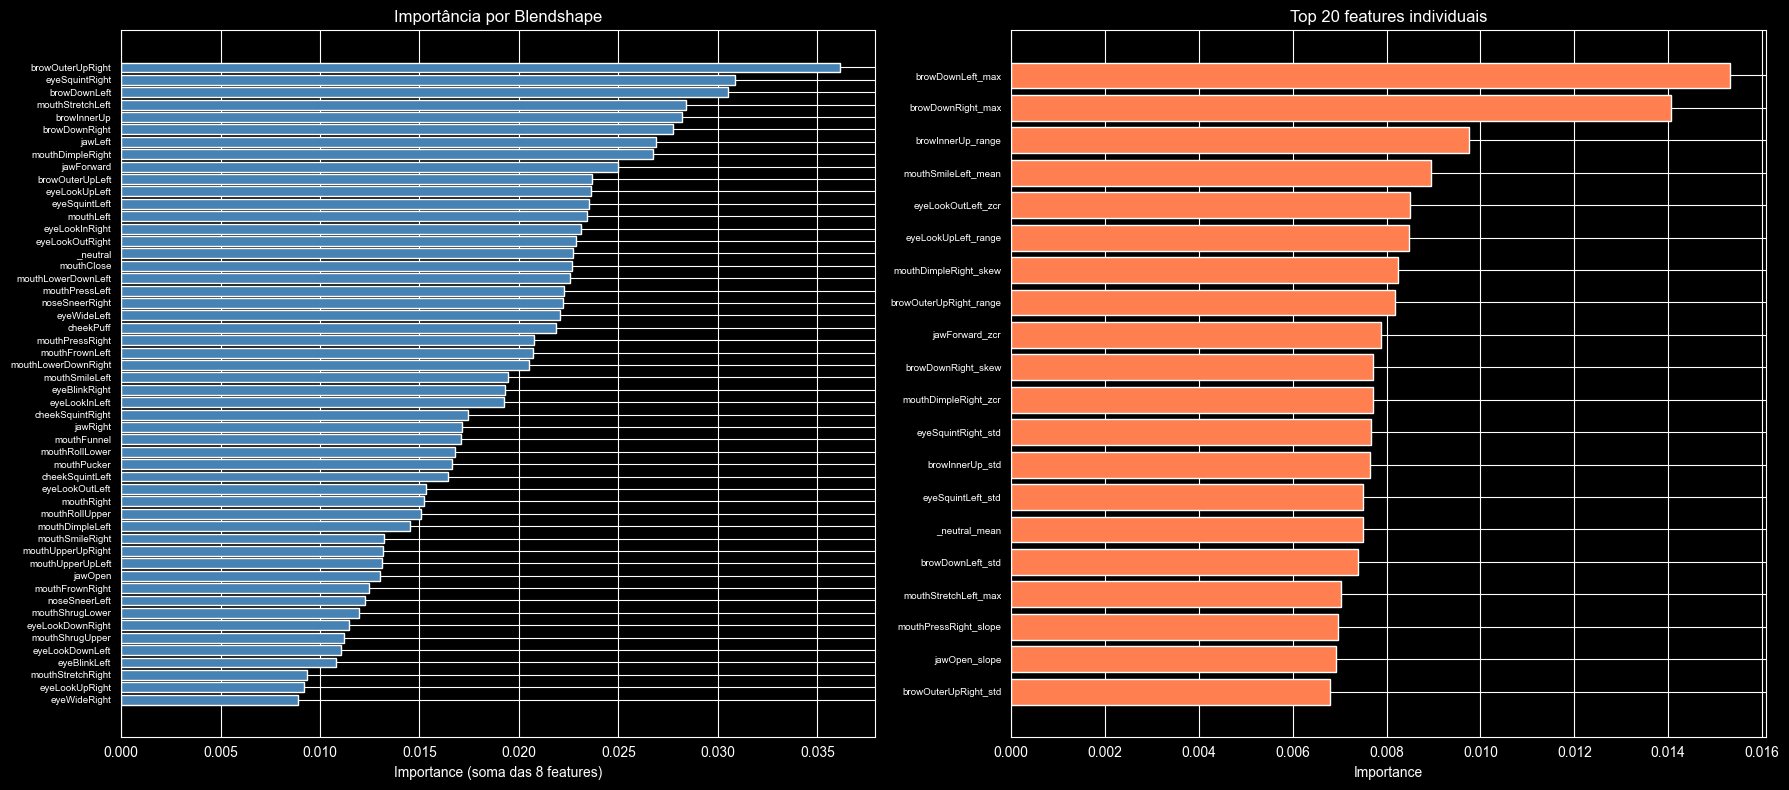

In [5]:
# CÉLULA 5: Feature importance
importances = best_model.feature_importances_

feat_names = ['mean', 'std', 'slope', 'range', 'iqr', 'zcr', 'max', 'skew']
bs_importances = {}
for i, bs_name in enumerate(BS_NAMES):
    start = i * 8
    bs_importances[bs_name] = importances[start:start+8].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BS-level importance
sorted_bs = sorted(bs_importances.items(), key=lambda x: -x[1])
names, vals = zip(*sorted_bs)
axes[0].barh(range(len(names)), vals, color='steelblue')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=7)
axes[0].set_xlabel('Importance (soma das 8 features)')
axes[0].set_title('Importância por Blendshape')
axes[0].invert_yaxis()

# Top 20 features individuais
full_names = [f"{BS_NAMES[i//8]}_{feat_names[i%8]}" for i in range(len(importances))]
top_idx = np.argsort(importances)[-20:][::-1]
axes[1].barh(range(20), importances[top_idx], color='coral')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([full_names[i] for i in top_idx], fontsize=7)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 20 features individuais')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# CÉLULA 6: Dataset LSTM com limpeza e normalização

class BSSequenceDataset(Dataset):
    def __init__(self, data_list, max_len=256, stats=None):
        self.items = []
        for item in data_list:
            seq = np.load(item['npy_path']).astype(np.float64)
            if len(seq) == 0:
                continue
            seq = np.nan_to_num(seq, nan=0.0, posinf=1.0, neginf=0.0)
            seq = np.clip(seq, 0.0, 5.0)
            self.items.append((seq, item['label']))
        self.max_len = max_len
        
        if stats is None:
            all_frames = np.vstack([item[0] for item in self.items])
            self.mean = np.mean(all_frames, axis=0)
            self.std = np.std(all_frames, axis=0)
            self.std[self.std < 1e-8] = 1.0
        else:
            self.mean, self.std = stats
    
    def get_stats(self):
        return (self.mean, self.std)
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        seq, label = self.items[idx]
        seq_len = len(seq)
        
        seq = (seq - self.mean) / self.std
        
        if seq_len > self.max_len:
            indices = np.linspace(0, seq_len - 1, self.max_len, dtype=int)
            seq = seq[indices]
            mask = np.ones(self.max_len)
        else:
            pad_len = self.max_len - seq_len
            seq = np.vstack([seq, np.zeros((pad_len, INPUT_DIM))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])
        
        return (
            torch.FloatTensor(seq),
            torch.FloatTensor(mask),
            torch.FloatTensor([label])
        )


MAX_LEN = 256
BATCH_SIZE = 32

train_dataset = BSSequenceDataset(train_data, max_len=MAX_LEN)
train_stats = train_dataset.get_stats()
val_dataset = BSSequenceDataset(val_data, max_len=MAX_LEN, stats=train_stats)
test_dataset = BSSequenceDataset(test_data, max_len=MAX_LEN, stats=train_stats)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

x, m, y = next(iter(train_loader))
print(f"NaN no batch: {torch.isnan(x).any().item()}")
print(f"Range: [{x.min():.3f}, {x.max():.3f}]")
print(f"Batch shapes: x={x.shape}, mask={m.shape}, y={y.shape}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

NaN no batch: False
Range: [-2.200, 69.426]
Batch shapes: x=torch.Size([32, 256, 52]), mask=torch.Size([32, 256]), y=torch.Size([32, 1])
Train: 598 | Val: 107 | Test: 427


In [7]:
# CÉLULA 7: Modelo LSTM (mesmo do AU, input_dim=52)

class BSLSTM(nn.Module):
    def __init__(self, input_dim=52, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x, mask):
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out).squeeze(-1)
        attn_weights = attn_weights.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        logits = self.classifier(context)
        return logits


model = BSLSTM(input_dim=INPUT_DIM, hidden_dim=64, n_layers=2, dropout=0.3).to(device)
print(f"Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Parâmetros: 176,386
BSLSTM(
  (lstm): LSTM(52, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [8]:
# CÉLULA 8: Treinar LSTM

n_pos = sum(d['label'] for d in train_data)
n_neg = len(train_data) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

N_EPOCHS = 50
best_val_f1 = 0
patience = 10
patience_counter = 0
history = {'train_loss': [], 'val_f1': []}

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0
    for x, mask, y in train_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x, mask)
        loss = criterion(logits, y)
        
        if torch.isnan(loss):
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step()
    avg_loss = total_loss / max(len(train_loader), 1)
    
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, mask, y in val_loader:
            x, mask = x.to(device), mask.to(device)
            logits = model(x, mask)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y.numpy().flatten())
    
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    history['train_loss'].append(avg_loss)
    history['val_f1'].append(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(BASE_DIR, 'best_bs_lstm.pt'))
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
              f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping na epoch {epoch+1}")
        break

print(f"\nMelhor Val Macro F1: {best_val_f1:.4f}")

Epoch   1 | Loss: 0.6978 | Val F1: 0.4969 | Best: 0.4969 *
Epoch   2 | Loss: 0.6929 | Val F1: 0.5764 | Best: 0.5764 *
Epoch   5 | Loss: 0.6618 | Val F1: 0.5655 | Best: 0.5764 
Epoch  10 | Loss: 0.5444 | Val F1: 0.5507 | Best: 0.5764 
Epoch  11 | Loss: 0.5040 | Val F1: 0.5844 | Best: 0.5844 *
Epoch  15 | Loss: 0.4224 | Val F1: 0.5531 | Best: 0.5844 
Epoch  20 | Loss: 0.3312 | Val F1: 0.5424 | Best: 0.5844 

Early stopping na epoch 21

Melhor Val Macro F1: 0.5844


LSTM Test Macro F1: 0.5615

              precision    recall  f1-score   support

       No AH       0.47      0.60      0.53       171
          AH       0.67      0.54      0.60       256

    accuracy                           0.56       427
   macro avg       0.57      0.57      0.56       427
weighted avg       0.59      0.56      0.57       427



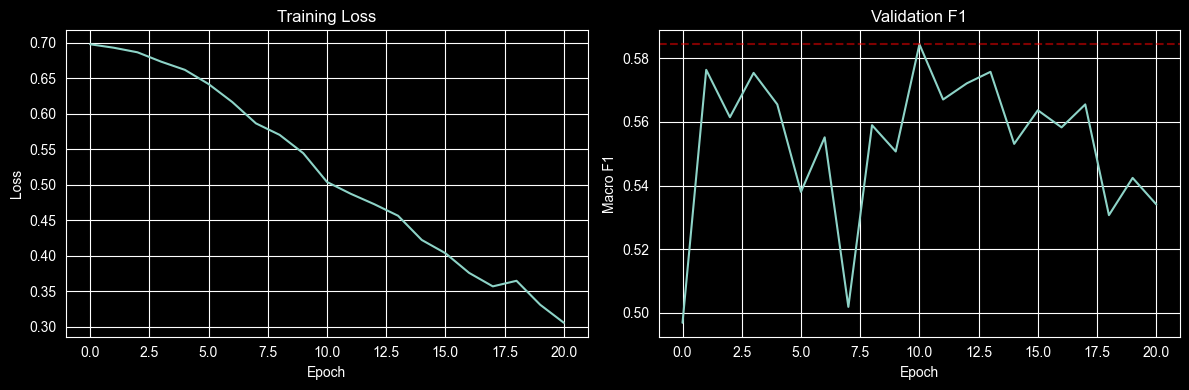

In [9]:
# CÉLULA 9: Avaliar LSTM no test set

model.load_state_dict(torch.load(os.path.join(BASE_DIR, 'best_bs_lstm.pt')))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask = x.to(device), mask.to(device)
        logits = model(x, mask)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y.numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())

test_f1_lstm = f1_score(all_labels, all_preds, average='macro')
print(f"LSTM Test Macro F1: {test_f1_lstm:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=['No AH', 'AH'])}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[1].plot(history['val_f1'])
axes[1].axhline(best_val_f1, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].set_title('Validation F1')
plt.tight_layout()
plt.show()

In [10]:
# CÉLULA 10: Comparativo final — AUs vs Blendshapes
print("=" * 55)
print("RESULTADOS — Modalidade Visual")
print("=" * 55)
print(f"{'Modelo':<35} {'Val F1':>8} {'Test F1':>8}")
print("-" * 55)
print(f"{'Challenge baseline':<35} {'—':>8} {'0.2827':>8}")
print("-" * 55)
print(f"{'AUs — XGBoost (temporal)':<35} {'0.6194':>8} {'0.5642':>8}")
print(f"{'AUs — LSTM + Attention':<35} {'0.5723':>8} {'0.5266':>8}")
print("-" * 55)
print(f"{'Blendshapes — XGBoost (temporal)':<35} {best_f1:>8.4f} {test_f1:>8.4f}")
print(f"{'Blendshapes — LSTM + Attention':<35} {best_val_f1:>8.4f} {test_f1_lstm:>8.4f}")
print("=" * 55)
print(f"\nTexto (BERT) referência:              0.5758   0.5904")
print(f"Fusão B (divergência) referência:      0.6524   0.7090")

RESULTADOS — Modalidade Visual
Modelo                                Val F1  Test F1
-------------------------------------------------------
Challenge baseline                         —   0.2827
-------------------------------------------------------
AUs — XGBoost (temporal)              0.6194   0.5642
AUs — LSTM + Attention                0.5723   0.5266
-------------------------------------------------------
Blendshapes — XGBoost (temporal)      0.5973   0.5712
Blendshapes — LSTM + Attention        0.5844   0.5615

Texto (BERT) referência:              0.5758   0.5904
Fusão B (divergência) referência:      0.6524   0.7090
